# 03 Check Keypoints output notebook

## Imports and paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("E:/Be_My_Ear")

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / "WLASL100"
KEYPOINT_DIR = BASE_DIR / "keypoints"

VIDEO_INDEX_FILE = BASE_DIR / "wlasl100_video_index.csv"
KEYPOINT_INDEX_FILE = BASE_DIR / "wlasl100_keypoint_index.csv"
LABEL_MAP_FILE = PROJECT_ROOT / "data" / "label_maps" / "asl_wlasl100_labels.json"

print("Base dir exists:", BASE_DIR.exists())
print("Keypoint dir exists:", KEYPOINT_DIR.exists())
print("Video index exists:", VIDEO_INDEX_FILE.exists())
print("Keypoint index exists:", KEYPOINT_INDEX_FILE.exists())
print("Label map exists:", LABEL_MAP_FILE.exists())

Base dir exists: True
Keypoint dir exists: True
Video index exists: True
Keypoint index exists: True
Label map exists: True


## Load video index

In [3]:
video_df = pd.read_csv(VIDEO_INDEX_FILE)

print("Videos in usable index:", len(video_df))
print("Classes:", video_df["label_id"].nunique())

video_df.head()

Videos in usable index: 1013
Classes: 100


,video_id,original_class_id,gloss,video_path,label_id
0,69422,27,orange,E:\Be_My_Ear\data\raw\ASL\videos\69422.mp4,67
1,10898,82,city,E:\Be_My_Ear\data\raw\ASL\videos\10898.mp4,20
2,10893,82,city,E:\Be_My_Ear\data\raw\ASL\videos\10893.mp4,20
3,10892,82,city,E:\Be_My_Ear\data\raw\ASL\videos\10892.mp4,20
4,10895,82,city,E:\Be_My_Ear\data\raw\ASL\videos\10895.mp4,20


## Check extracted .npy files

In [4]:
keypoint_files = list(KEYPOINT_DIR.glob("*.npy"))

print("Total extracted keypoint files:", len(keypoint_files))
print("Expected usable videos:", len(video_df))

keypoint_files[:5]

Total extracted keypoint files: 1013
Expected usable videos: 1013


[WindowsPath('E:/Be_My_Ear/data/processed/ASL/WLASL100/keypoints/10147.npy'),
 WindowsPath('E:/Be_My_Ear/data/processed/ASL/WLASL100/keypoints/10148.npy'),
 WindowsPath('E:/Be_My_Ear/data/processed/ASL/WLASL100/keypoints/10149.npy'),
 WindowsPath('E:/Be_My_Ear/data/processed/ASL/WLASL100/keypoints/10151.npy'),
 WindowsPath('E:/Be_My_Ear/data/processed/ASL/WLASL100/keypoints/10157.npy')]

## Create/check keypoint index

In [5]:
records = []

for _, row in video_df.iterrows():
    video_id = str(row["video_id"])
    keypoint_path = KEYPOINT_DIR / f"{video_id}.npy"

    if keypoint_path.exists():
        records.append({
            "video_id": video_id,
            "gloss": row["gloss"],
            "label_id": int(row["label_id"]),
            "original_class_id": int(row["original_class_id"]),
            "video_path": row["video_path"],
            "keypoint_path": str(keypoint_path)
        })

keypoint_df = pd.DataFrame(records)

keypoint_df.to_csv(KEYPOINT_INDEX_FILE, index=False)

print("Saved keypoint index to:")
print(KEYPOINT_INDEX_FILE)

print("\nTotal keypoint samples:", len(keypoint_df))
print("Total classes:", keypoint_df["label_id"].nunique())

keypoint_df.head()

Saved keypoint index to:
E:\Be_My_Ear\data\processed\ASL\WLASL100\wlasl100_keypoint_index.csv

Total keypoint samples: 1013
Total classes: 100


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path
0,69422,orange,67,27,E:\Be_My_Ear\data\raw\ASL\videos\69422.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...
1,10898,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10898.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...
2,10893,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10893.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...
3,10892,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10892.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...
4,10895,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10895.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...


## Check missing keypoints

In [6]:
expected_ids = set(video_df["video_id"].astype(str))
actual_ids = set([p.stem for p in KEYPOINT_DIR.glob("*.npy")])

missing_keypoints = expected_ids - actual_ids

print("Missing keypoint files:", len(missing_keypoints))

list(missing_keypoints)[:20]

Missing keypoint files: 0


[]

## Check one sample file

In [7]:
sample_path = keypoint_df.iloc[0]["keypoint_path"]
sample = np.load(sample_path)

print("Sample file:", sample_path)
print("Shape:", sample.shape)
print("Data type:", sample.dtype)
print("Min value:", sample.min())
print("Max value:", sample.max())
print("Mean value:", sample.mean())

Sample file: E:\Be_My_Ear\data\processed\ASL\WLASL100\keypoints\69422.npy
Shape: (60, 258)
Data type: float32
Min value: -1.1773801
Max value: 2.0495439
Mean value: 0.26994208


## Check all file shapes

In [8]:
shape_records = []

for _, row in keypoint_df.iterrows():
    path = row["keypoint_path"]
    arr = np.load(path)

    shape_records.append({
        "video_id": row["video_id"],
        "gloss": row["gloss"],
        "label_id": row["label_id"],
        "shape": arr.shape,
        "num_frames": arr.shape[0],
        "num_features": arr.shape[1] if len(arr.shape) == 2 else None
    })

shape_df = pd.DataFrame(shape_records)

shape_df.head()

,video_id,gloss,label_id,shape,num_frames,num_features
0,69422,orange,67,"(60, 258)",60,258
1,10898,city,20,"(60, 258)",60,258
2,10893,city,20,"(60, 258)",60,258
3,10892,city,20,"(60, 258)",60,258
4,10895,city,20,"(60, 258)",60,258


## Confirm shape quality

In [9]:
print("Unique shapes:")
print(shape_df["shape"].value_counts())

bad_shapes = shape_df[
    (shape_df["num_frames"] != 60) | 
    (shape_df["num_features"] != 258)
]

print("\nBad shape files:", len(bad_shapes))

bad_shapes.head()

Unique shapes:
shape
(60, 258)    1013
Name: count, dtype: int64

Bad shape files: 0


,video_id,gloss,label_id,shape,num_frames,num_features


## Check class distribution

In [10]:
class_counts = keypoint_df["gloss"].value_counts()

print("Total classes:", len(class_counts))
print("Minimum samples per class:", class_counts.min())
print("Maximum samples per class:", class_counts.max())
print("Average samples per class:", round(class_counts.mean(), 2))

class_counts.head(20)

Total classes: 100
Minimum samples per class: 5
Maximum samples per class: 16
Average samples per class: 10.13


gloss
before          16
cool            16
thin            16
drink           15
go              15
cousin          14
who             14
computer        14
help            14
tall            13
candy           13
thanksgiving    13
bed             13
accident        13
bowling         13
short           13
yes             12
basketball      12
shirt           12
dark            12
Name: count, dtype: int64

## Visualise class distribution

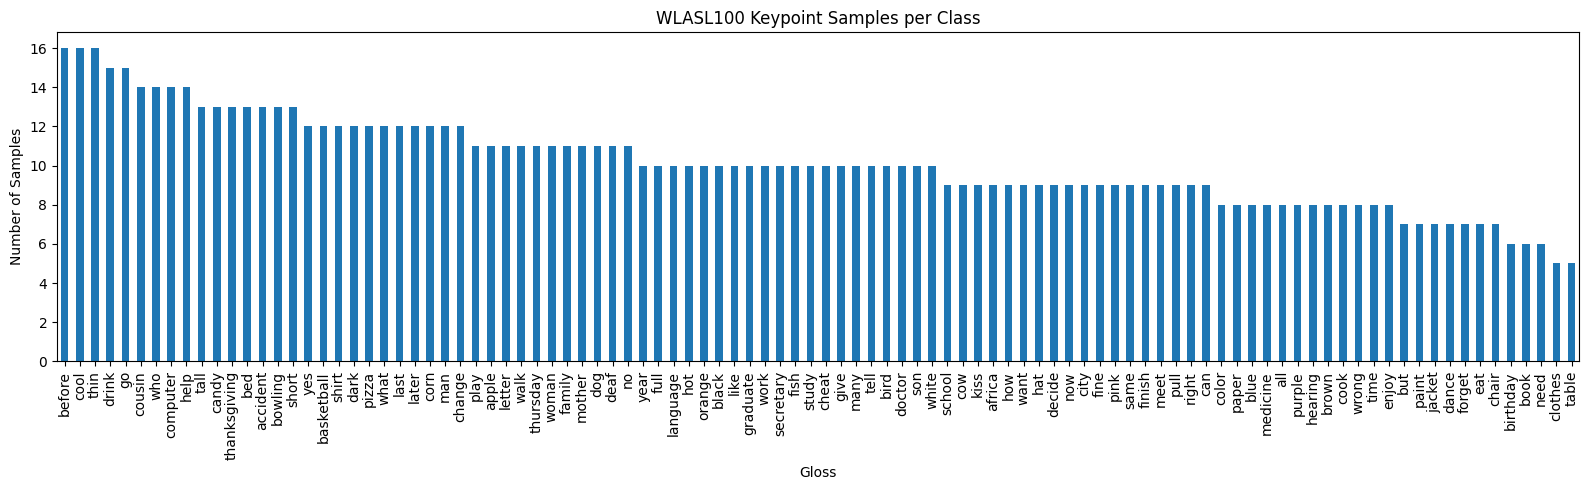

In [11]:
plt.figure(figsize=(16, 5))
class_counts.plot(kind="bar")
plt.title("WLASL100 Keypoint Samples per Class")
plt.xlabel("Gloss")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Check zero values

In [12]:
zero_stats = []

for _, row in keypoint_df.iterrows():
    arr = np.load(row["keypoint_path"])
    zero_ratio = np.mean(arr == 0)

    zero_stats.append({
        "video_id": row["video_id"],
        "gloss": row["gloss"],
        "label_id": row["label_id"],
        "zero_ratio": zero_ratio
    })

zero_df = pd.DataFrame(zero_stats)

print("Average zero ratio:", round(zero_df["zero_ratio"].mean(), 4))
print("Highest zero ratio:", round(zero_df["zero_ratio"].max(), 4))

zero_df.sort_values("zero_ratio", ascending=False).head(10)

Average zero ratio: 0.2617
Highest zero ratio: 0.5014


,video_id,gloss,label_id,zero_ratio
1005,63237,who,94,0.501357
833,63236,who,94,0.488760
802,6474,black,9,0.468411
4,10895,city,20,0.464341
199,42833,pink,70,0.448062
437,8915,candy,16,0.447674
682,13630,cousin,27,0.447674
206,6832,blue,10,0.439535
397,45436,purple,74,0.435853
59,26975,hearing,48,0.435853


## Save clean training index

This removes files with wrong shapes. It also optionally removes files where almost everything is zero.

In [13]:
valid_records = []

for _, row in keypoint_df.iterrows():
    arr = np.load(row["keypoint_path"])
    zero_ratio = np.mean(arr == 0)

    if arr.shape == (60, 258) and zero_ratio < 0.95:
        valid_records.append({
            "video_id": row["video_id"],
            "gloss": row["gloss"],
            "label_id": int(row["label_id"]),
            "original_class_id": int(row["original_class_id"]),
            "video_path": row["video_path"],
            "keypoint_path": row["keypoint_path"],
            "zero_ratio": zero_ratio
        })

clean_df = pd.DataFrame(valid_records)

CLEAN_INDEX_FILE = BASE_DIR / "wlasl100_clean_keypoint_index.csv"
clean_df.to_csv(CLEAN_INDEX_FILE, index=False)

print("Saved clean training index to:")
print(CLEAN_INDEX_FILE)

print("\nClean samples:", len(clean_df))
print("Clean classes:", clean_df["label_id"].nunique())

clean_df.head()

Saved clean training index to:
E:\Be_My_Ear\data\processed\ASL\WLASL100\wlasl100_clean_keypoint_index.csv

Clean samples: 1013
Clean classes: 100


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,69422,orange,67,27,E:\Be_My_Ear\data\raw\ASL\videos\69422.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.321512
1,10898,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10898.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.126163
2,10893,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10893.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.264535
3,10892,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10892.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.170930
4,10895,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10895.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.464341


In [14]:
print("Final preprocessing summary")
print("---------------------------")
print("Original usable videos:", len(video_df))
print("Extracted keypoint files:", len(keypoint_df))
print("Clean training samples:", len(clean_df))
print("Number of classes:", clean_df["label_id"].nunique())
print("Input shape for model: (60, 258)")

Final preprocessing summary
---------------------------
Original usable videos: 1013
Extracted keypoint files: 1013
Clean training samples: 1013
Number of classes: 100
Input shape for model: (60, 258)
